In [1]:
#Step 1 Generates a dataset of shape images in COCO format
import subprocess
import os
import shutil

# Define dataset path
dataset_path = "./shapes_dataset"

# Paths for images and annotations
images_dir = os.path.join(dataset_path, "images")
annotations_dir = os.path.join(dataset_path, "annotations")

# Clear the directories before generating new files
if os.path.exists(images_dir):
    shutil.rmtree(images_dir)
    print(f"✅ Cleared old images from: {images_dir}")
else:
    print(f"⚠️ No existing images directory found at: {images_dir}")

if os.path.exists(annotations_dir):
    shutil.rmtree(annotations_dir)
    print(f"✅ Cleared old annotations from: {annotations_dir}")
else:
    print(f"⚠️ No existing annotations directory found at: {annotations_dir}")

# Recreate the directories
os.makedirs(images_dir)
os.makedirs(annotations_dir)
print(f"✅ Created new directories for images and annotations at: {dataset_path}")

# Set dynamic parameters
num_images = 5  # Change this dynamically if needed
image_width = 128  # Change this dynamically if needed
image_height = 128  # Change this dynamically if needed

# Run the dataset generation script inside Jupyter
command = [
    "python", "shapes/run.py",
    "--save_dir", dataset_path,
    "--num_images", str(num_images),
    "--image_size", str(image_width), str(image_height),  # ✅ Explicitly setting image size dynamically
    "--task_type", "segmentation"
]

# Execute the command
result = subprocess.run(command, capture_output=True, text=True)
print(result.stdout)  # Print output for debugging

# Check if dataset is created
coco_annotations_file = os.path.join(annotations_dir, "coco_annotations.json")

if not os.path.exists(coco_annotations_file):
    print("❌ ERROR: Dataset not generated correctly! Check run.py.")
else:
    print(f"✅ Shapes dataset successfully generated with {num_images} images of size {image_width}x{image_height}!")
    print(f"Images are saved in: {images_dir}")
    print(f"Annotations are saved in: {annotations_dir}")
    print(f"COCO annotations file: {coco_annotations_file}")

✅ Cleared old images from: ./shapes_dataset/images
✅ Cleared old annotations from: ./shapes_dataset/annotations
✅ Created new directories for images and annotations at: ./shapes_dataset
Generated dataset in ./shapes_dataset

❌ ERROR: Dataset not generated correctly! Check run.py.


In [2]:
#Step 2: Load and Verify COCO Annotations
import json

# Define the correct path for the COCO annotations file
OUTPUT_ANNOTATION_FILE = "./shapes_dataset/annotations/coco_annotations.json"

# Verify COCO Annotations
try:
    with open(OUTPUT_ANNOTATION_FILE, "r") as f:
        coco_data = json.load(f)
        # Debugging: Loop over annotations and extract bounding boxes
    for ann in coco_data["annotations"]:
        x, y, w, h = map(int, ann["bbox"])  # Extract coordinates and size
        print(f"🖼 Object | BBox: ({x}, {y}, {w}, {h}) | Size: ({w}x{h})")
        #print(f"🖼 Object | BBox: ({x}, {y}, {x+w}, {y+h}) | Size: ({w}x{h})")


    # Show structure
    print("✅ COCO Annotations Loaded Successfully!")
    print(json.dumps(coco_data, indent=4)[:1000])  # Print first 1000 characters

except FileNotFoundError:
    print(f"❌ ERROR: The file {OUTPUT_ANNOTATION_FILE} was not found. Make sure it was generated correctly!")

❌ ERROR: The file ./shapes_dataset/annotations/coco_annotations.json was not found. Make sure it was generated correctly!


In [3]:
#step 3 with iou and dice
import os
import json
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor

# ============================
# 🔹 Load SAM Model with Debugging
# ============================

CHECKPOINT_URL = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
WEIGHTS_DIR = "/Users/ma/Documents/samThesis/segment-anything/weights"
CHECKPOINT_PATH = os.path.join(WEIGHTS_DIR, "sam_vit_h_4b8939.pth")

# Create directory if needed
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Download checkpoint if not exists
if not os.path.isfile(CHECKPOINT_PATH):
    os.system(f"curl -o {CHECKPOINT_PATH} {CHECKPOINT_URL}")
    print(f"✅ Downloaded SAM checkpoint to: {CHECKPOINT_PATH}")
else:
    print(f"✅ Checkpoint already exists at: {CHECKPOINT_PATH}")

# Load SAM model
sam = sam_model_registry["vit_h"](checkpoint=CHECKPOINT_PATH)
predictor = SamPredictor(sam)

# ============================
# 🔹 Load COCO Annotations with Debugging
# ============================

DATASET_PATH = "./shapes_dataset"
ANNOTATION_FILE = os.path.join(DATASET_PATH, "annotations/coco_annotations.json")
OUTPUT_ANNOTATION_FILE = os.path.join(DATASET_PATH, "annotations/coco_annotations_with_masks.json")

# Check if annotation file exists
if not os.path.exists(ANNOTATION_FILE):
    print(f"❌ ERROR: COCO annotation file not found: {ANNOTATION_FILE}")
    raise FileNotFoundError(f"COCO annotation file {ANNOTATION_FILE} does not exist!")

# Load COCO JSON
with open(ANNOTATION_FILE, "r") as f:
    coco_data = json.load(f)

print(f"✅ Loaded COCO annotations from {ANNOTATION_FILE}")
print(f"🔹 Total Images: {len(coco_data['images'])} | Total Annotations: {len(coco_data['annotations'])}")

# Debug: Check if images exist
if len(coco_data["images"]) == 0:
    print("⚠️ WARNING: No images found in COCO annotations! Check dataset generation.")
    raise ValueError("COCO dataset has no images!")

# Debug: Check if annotations exist
if len(coco_data["annotations"]) == 0:
    print("⚠️ WARNING: No annotations found in COCO annotations! Expected bounding boxes.")
    raise ValueError("COCO dataset has no annotations!")

# ============================
# 🔹 Calculate IoU and Dice Coefficient
# ============================

# Function to calculate IoU
def calculate_iou(mask_true, mask_pred):
    intersection = np.sum(np.logical_and(mask_true, mask_pred))
    union = np.sum(np.logical_or(mask_true, mask_pred))
    iou = intersection / union if union != 0 else 0  # Avoid division by zero
    return iou

# Function to calculate Dice coefficient
def calculate_dice(mask_true, mask_pred):
    intersection = np.sum(np.logical_and(mask_true, mask_pred))
    dice = (2 * intersection) / (np.sum(mask_true) + np.sum(mask_pred)) if (np.sum(mask_true) + np.sum(mask_pred)) != 0 else 0
    return dice

new_annotations = []
masks_generated = 0
no_masks_found = 0

# For final summary of results
image_summary = []

for img_info in coco_data["images"]:
    img_path = os.path.join(DATASET_PATH, "images", img_info["file_name"])

    # Check if image exists
    if not os.path.exists(img_path):
        print(f"⚠️ Skipping: {img_info['file_name']} (File Not Found)")
        continue

    # Load image
    image = cv2.imread(img_path)
    
    # Debugging: Print image size after loading
    original_img_width, original_img_height = image.shape[0], image.shape[1]
    print(f"📌 Loaded {img_info['file_name']} | Image Size: {image.shape[:2]} (Height, Width) | original img w: {original_img_width} | original img h: {original_img_height}")

    # Convert image to RGB for SAM model
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    predictor.set_image(image)

    # Initialize variables to track masks and image dimensions
    processed_img_width, processed_img_height = image.shape[1], image.shape[0]
    masks_detected_per_image = 0
    masks_generated_per_image = 0

    # Save before processing details for final summary
    image_summary.append({
        "image_name": img_info['file_name'],
        "before_processing_dimensions": (original_img_width, original_img_height),
        "bounding_boxes": [],
        "masks_detected": 0,
        "masks_generated": 0,
        "no_masks_found": 0,
        "iou_scores": [],  # Store IoU scores
        "dice_scores": []  # Store Dice scores
    })

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(image)

    # Get annotations for the current image
    img_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == img_info["id"]]

    for ann in img_annotations:
        bbox = ann["bbox"]
        x, y, w, h = map(int, bbox)

        # Adjusted Input Box for SAM (using absolute coordinates)
        input_box = np.array([x, y, w, h])

        # Debugging: Print bounding box details for SAM
        print(f"🛠 Input Box for SAM: {input_box}")

        # Run SAM for segmentation mask generation
        sam_masks, _, _ = predictor.predict(box=input_box)

        if len(sam_masks) == 0:
            print(f"⚠️ No masks found for {img_info['file_name']}! Skipping annotation.")
            no_masks_found += 1
            continue
        else:
            print(f"✅ {len(sam_masks)} masks detected.")
            masks_detected_per_image += len(sam_masks)

        # Initialize variables for IoU and Dice for the current image
        iou_list = []
        dice_list = []

        for mask in sam_masks:
            # Assuming ground truth mask is available (you can modify this if required)
            ground_truth_mask = np.ones_like(mask)  # Replace with your actual ground truth mask

            # Calculate IoU and Dice
            iou_score = calculate_iou(ground_truth_mask, mask)
            dice_score = calculate_dice(ground_truth_mask, mask)

            # Append IoU and Dice scores to the lists
            iou_list.append(iou_score)
            dice_list.append(dice_score)

            # Add to new annotations with segmentation mask
            mask_indices = np.argwhere(mask)  # Get mask pixel positions
            mask_indices = mask_indices.astype(np.float32)  # Ensure float precision

            segmentation = mask_indices.flatten().tolist()

            new_annotations.append({
                "id": len(new_annotations) + 1,
                "image_id": img_info["id"],
                "category_id": ann["category_id"],
                "segmentation": [segmentation],  # List of coordinates
                "area": int(np.sum(mask)),  # Mask area
                "bbox": ann["bbox"],  # Keep original bbox
                "iscrowd": 0
            })

        # Add IoU and Dice scores to image summary
        image_summary[-1]["iou_scores"].append(iou_list)
        image_summary[-1]["dice_scores"].append(dice_list)

    plt.show()  # Show visualization per image

    image_summary[-1]["after_processing_dimensions"] = (processed_img_width, processed_img_height)
    image_summary[-1]["masks_detected"] = masks_detected_per_image
    image_summary[-1]["masks_generated"] = masks_generated_per_image
    image_summary[-1]["no_masks_found"] = no_masks_found

# ============================
# 🔹 Save Updated COCO Annotations
# ============================

coco_data["annotations"] = new_annotations
with open(OUTPUT_ANNOTATION_FILE, "w") as f:
    json.dump(coco_data, f, indent=4)

# Display IoU and Dice results after processing all images
for img_info in image_summary:
    print(f"\nSummary for {img_info['image_name']}:")
    print(f"  🔹 Masks Detected: {img_info['masks_detected']}")
    print(f"  🔹 IoU Scores: {img_info['iou_scores']}")
    print(f"  🔹 Dice Scores: {img_info['dice_scores']}")


✅ Checkpoint already exists at: /Users/ma/Documents/samThesis/segment-anything/weights/sam_vit_h_4b8939.pth
❌ ERROR: COCO annotation file not found: ./shapes_dataset/annotations/coco_annotations.json


FileNotFoundError: COCO annotation file ./shapes_dataset/annotations/coco_annotations.json does not exist!

In [ ]:
# Step 3: Load SAM Model & Process COCO Annotations with Visualization
import os
import json
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor

# ============================
# 🔹 Load SAM Model with Debugging
# ============================

CHECKPOINT_URL = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
WEIGHTS_DIR = "/Users/ma/Documents/samThesis/segment-anything/weights"
CHECKPOINT_PATH = os.path.join(WEIGHTS_DIR, "sam_vit_h_4b8939.pth")

# Create directory if needed
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Download checkpoint if not exists
if not os.path.isfile(CHECKPOINT_PATH):
    os.system(f"curl -o {CHECKPOINT_PATH} {CHECKPOINT_URL}")
    print(f"✅ Downloaded SAM checkpoint to: {CHECKPOINT_PATH}")
else:
    print(f"✅ Checkpoint already exists at: {CHECKPOINT_PATH}")

# Load SAM model
sam = sam_model_registry["vit_h"](checkpoint=CHECKPOINT_PATH)
predictor = SamPredictor(sam)

# ============================
# 🔹 Load COCO Annotations with Debugging
# ============================

DATASET_PATH = "./shapes_dataset"
ANNOTATION_FILE = os.path.join(DATASET_PATH, "annotations/coco_annotations.json")
OUTPUT_ANNOTATION_FILE = os.path.join(DATASET_PATH, "annotations/coco_annotations_with_masks.json")

# Check if annotation file exists
if not os.path.exists(ANNOTATION_FILE):
    print(f"❌ ERROR: COCO annotation file not found: {ANNOTATION_FILE}")
    raise FileNotFoundError(f"COCO annotation file {ANNOTATION_FILE} does not exist!")

# Load COCO JSON
with open(ANNOTATION_FILE, "r") as f:
    coco_data = json.load(f)

print(f"✅ Loaded COCO annotations from {ANNOTATION_FILE}")
print(f"🔹 Total Images: {len(coco_data['images'])} | Total Annotations: {len(coco_data['annotations'])}")

# Debug: Check if images exist
if len(coco_data["images"]) == 0:
    print("⚠️ WARNING: No images found in COCO annotations! Check dataset generation.")
    raise ValueError("COCO dataset has no images!")

# Debug: Check if annotations exist
if len(coco_data["annotations"]) == 0:
    print("⚠️ WARNING: No annotations found in COCO annotations! Expected bounding boxes.")
    raise ValueError("COCO dataset has no annotations!")

# ============================
# 🔹 Run SAM on Each Image & Generate Masks (with Normalization & Visualization)
# ============================

new_annotations = []
masks_generated = 0
no_masks_found = 0

# For final summary of results
image_summary = []

for img_info in coco_data["images"]:
    img_path = os.path.join(DATASET_PATH, "images", img_info["file_name"])

    # Check if image exists
    if not os.path.exists(img_path):
        print(f"⚠️ Skipping: {img_info['file_name']} (File Not Found)")
        continue

    # Load image
    image = cv2.imread(img_path)
    
    # Debugging: Print image size after loading
    original_img_width, original_img_height = image.shape[0], image.shape[1]
    print(f"📌 Loaded {img_info['file_name']} | Image Size: {image.shape[:2]} (Height, Width) | original img w: {original_img_width} | original img h: {original_img_height}")

    # ============================
    # 🔹 Visualization of Original Shapes (Before SAM Processing)
    # ============================
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(image)

    # Visualize the bounding boxes for debugging
    img_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == img_info["id"]]
    #min_x=5000
    #min_y=5000
    #max_x=-5000
    #max_y=-5000
    for ann in img_annotations:
        bbox = ann["bbox"]
        x, y, w, h = map(int, bbox)
    #    if (x<min_x):
    #        min_x=x
    #    if (x >max_x):
    #        max_x=x
    #    if (y<min_y):
    #        min_y=y
    #    if (y >max_y):
    #        max_y=y
        #4 if conditions for each case 

    #    print(f"printing mix and max values: {min_x} , {max_x}, {min_y}, {max_y} ")

        # Draw bounding box around the original shapes
        rect = plt.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

    # Display the image with bounding boxes
    plt.title(f"Visualizing Original Shapes in {img_info['file_name']}")
    plt.xlim(-100, 200)
    #plt.xlim(min_x, max_x)
    #plt.ylim(min_y, max_y)
    plt.show()

    # Convert image to RGB for SAM model
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    predictor.set_image(image)

    # Initialize variables to track masks and image dimensions
    processed_img_width, processed_img_height = image.shape[1], image.shape[0]
    masks_detected_per_image = 0
    masks_generated_per_image = 0

    # Save before processing details for final summary
    image_summary.append({
        "image_name": img_info['file_name'],
        "before_processing_dimensions": (original_img_width, original_img_height),
        "bounding_boxes": [],
        "masks_detected": 0,
        "masks_generated": 0,
        "no_masks_found": 0
    })

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(image)

    for ann in img_annotations:
        bbox = ann["bbox"]
        x, y, w, h = map(int, bbox)

        # Adjusted Input Box for SAM (using absolute coordinates)
        input_box = np.array([x, y, w, h])

        # Debugging: Print bounding box details for SAM
        print(f"🛠 Input Box for SAM: {input_box}")

        # Run SAM for segmentation mask generation
        sam_masks, _, _ = predictor.predict(box=input_box)

        # Debugging: Check if SAM generated masks
        if len(sam_masks) == 0:
            print(f"⚠️ No masks found for {img_info['file_name']}! Skipping annotation.")
            no_masks_found += 1
            continue
        else:
            print(f"✅ {len(sam_masks)} masks detected.")
            masks_detected_per_image += len(sam_masks)

        # ✅ Draw Bounding Box
        rect = plt.Rectangle((x, y), w, h, edgecolor="red", facecolor="none", linewidth=2)
        ax.add_patch(rect)

        # Normalize & Convert Mask to COCO Segmentation Format
        for mask in sam_masks:
            mask_indices = np.argwhere(mask)  # Get mask pixel positions
            mask_indices = mask_indices.astype(np.float32)  # Ensure float precision

            # Normalize the mask positions relative to the image size
            mask_indices[:, 0] /= original_img_height  # Normalize Y
            mask_indices[:, 1] /= original_img_width   # Normalize X

            # Scale back to pixel values for COCO format
            mask_indices[:, 0] *= original_img_height
            mask_indices[:, 1] *= original_img_width

            segmentation = mask_indices.flatten().tolist()

            # Convert mask to 0/1 binary format for better display
            mask = np.uint8(mask)  # Convert to uint8 (0 or 255 for black and white mask)
            
            # Display the mask with better contrast and transparency
            ax.imshow(mask, alpha=0.5, cmap="jet")  # Use 'jet' colormap or try 'hsv' for more contrast
            ax.imshow(image, alpha=0.5)  # Show original image with some transparency to overlay the mask

            # Save updated annotation with segmentation mask
            if segmentation:
                new_annotations.append({
                    "id": len(new_annotations) + 1,
                    "image_id": img_info["id"],
                    "category_id": ann["category_id"],
                    "segmentation": [segmentation],  # List of coordinates
                    "area": int(np.sum(mask)),  # Mask area
                    "bbox": ann["bbox"],  # Keep original bbox
                    "iscrowd": 0
                })
                masks_generated += 1
                masks_generated_per_image += 1

    plt.show()  # Show visualization per image

    # Save processed image details for final summary
    processed_img_width, processed_img_height = image.shape[1], image.shape[0]
    
    # Check if image dimensions changed (resized)
    if (processed_img_width, processed_img_height) != (original_img_width, original_img_height):
        print(f"⚠️ Image {img_info['file_name']} was resized during processing!")

    image_summary[-1]["after_processing_dimensions"] = (processed_img_width, processed_img_height)
    image_summary[-1]["masks_detected"] = masks_detected_per_image
    image_summary[-1]["masks_generated"] = masks_generated_per_image
    image_summary[-1]["no_masks_found"] = no_masks_found

# ============================
# 🔹 Save Updated COCO Annotations
# ============================

# Update annotations in COCO JSON
coco_data["annotations"] = new_annotations

# Save updated COCO JSON
with open(OUTPUT_ANNOTATION_FILE, "w") as f:
    json.dump(coco_data, f, indent=4)

# Debugging Summary After Processing All Images
print("\n✅ SAM Masks Generated and Saved in COCO Format!")
print(f"🔹 Total Images Processed: {len(coco_data['images'])} | Masks Generated: {masks_generated} | No Masks: {no_masks_found}")

# Final Full Summary of Results:
print("\n🔹 Full Summary of Results:")
for img_info in image_summary:
    print(f"\n📌 {img_info['image_name']} - Before and After Processing:")
    print(f"   🔹 Before Processing - Size: {img_info['before_processing_dimensions']}")
    print(f"   🔹 After Processing - Size: {img_info['after_processing_dimensions']}")
    print(f"   🔹 Masks Detected: {img_info['masks_detected']}")
    print(f"   🔹 Masks Generated: {img_info['masks_generated']}")
    print(f"   🔹 No Masks Found: {img_info['no_masks_found']}")

# Final validation check
if len(new_annotations) == 0:
    print("❌ ERROR: No segmentation data generated! Check SAM mask outputs.")

In [ ]:
# Step 4: Verify Updated COCO Annotations
# Load updated COCO annotations
with open(OUTPUT_ANNOTATION_FILE, "r") as f:
    updated_coco_data = json.load(f)
# Debugging: Loop over annotations and extract bounding boxes
for ann in coco_data["annotations"]:
    x, y, w, h = map(int, ann["bbox"])  # Extract coordinates and size
    print(f"🖼 Object | BBox: ({x}, {y}, {x+w}, {y+h}) | Size: ({w}x{h})")

# Check if segmentation is now included
sample_ann = next((ann for ann in updated_coco_data["annotations"] if "segmentation" in ann), None)

if sample_ann:
    print("✅ Segmentation Data Found in COCO Format!")
    print(json.dumps(sample_ann, indent=4))
else:
    print("❌ ERROR: No segmentation data found. Ensure SAM generated masks correctly!")


In [ ]:
# Full Summary of Results (IoU & Dice) < calculated in step 3
print("\n🔹 Full Summary of Results (IoU & Dice):")
for img_info in image_summary:
    print(f"\n📌 {img_info['image_name']} - Before and After Processing:")
    print(f"   🔹 IoU Scores: {img_info['iou_scores']}")
    print(f"   🔹 Dice Scores: {img_info['dice_scores']}")

In [ ]:
# Step 5: Visualize the Segmentation Masks
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# Define the directory where your images are stored
image_dir = "./shapes_dataset/images"  # Adjust this path as necessary

# Define custom colors for each category
category_colors = {
    1: 'orange',   # Category 1 (e.g., "circle")
    2: 'pink',  # Category 2 (e.g., "rectangle")
}

# Pick a random image
image_id = np.random.choice(len(updated_coco_data["images"]))
image_info = updated_coco_data["images"][image_id]
image_path = os.path.join(image_dir, image_info["file_name"])

# Load image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Create the plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image)

# Iterate through annotations and plot the segmentation masks with appropriate colors
for ann in updated_coco_data["annotations"]:
    if ann["image_id"] == image_info["id"]:
        for seg in ann["segmentation"]:
            poly = np.array(seg).reshape(-1, 2)
            # Get the color for the category, default to 'gray' if not found
            color = category_colors.get(ann['category_id'], 'gray')  
            ax.plot(poly[:, 0], poly[:, 1], linewidth=2, label=f"Shape {ann['category_id']}", color=color)

# Display the legend
ax.legend()

# Show the plot
plt.show()

# Experiment 2

In [1]:
#step1: Install Required Packages
!pip install opencv-python pycocotools tqdm matplotlib
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /private/var/folders/8c/4541z2b93d74vbzt0pxzpz_m0000gn/T/pip-req-build-xdiv7fmk
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /private/var/folders/8c/4541z2b93d74vbzt0pxzpz_m0000gn/T/pip-req-build-xdiv7fmk
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done


In [1]:
#step1.1
import os

# Define your dynamic path variables
SHAPES_FOLDER = "shapes"        # folder containing run.py, visualize.py
DATASET_NAME  = "shapes_dataset" # subfolder name for your dataset

# 1) Set your HOME path
os.environ["HOME"] = "/Users/ma/Documents/samThesis/segment-anything/notebooks/S1-COCO-v1"

# 2) Print to confirm
print("HOME is now:", os.environ["HOME"])

HOME is now: /Users/ma/Documents/samThesis/segment-anything/notebooks/S1-COCO-v1


In [2]:
#rm -rf ./shapes_dataset

In [3]:
#step2: Generate the Shapes Dataset
import subprocess
import os

# Modify these as you like
NUM_IMAGES = 1
IMG_WIDTH = 500
IMG_HEIGHT = 500
SAVE_DIR = f"./{DATASET_NAME}"   # We'll store the dataset in "shapes_dataset" (relative to SHAPES_FOLDER)

# Make sure the directory exists
os.makedirs(SAVE_DIR, exist_ok=True)

command = [
    "python", "run.py",
    "--save_dir", SAVE_DIR,      # e.g. "./shapes_dataset"
    "--task_type", "detection",
    "--num_images", str(NUM_IMAGES),
    "--image_size", str(IMG_WIDTH), str(IMG_HEIGHT),
    "--shapes", "circle", "rect",
    "--shape_color", "blue",     # Force shapes to be blue
    "--shuffle_color", "False"   # Turn off color shuffling
]

# We'll run this script from inside SHAPES_FOLDER
result = subprocess.run(command, cwd=SHAPES_FOLDER, capture_output=True, text=True)

print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)
print("Dataset generated at:", SAVE_DIR)
print("Check subfolders like 'images' and 'labels_json' within it...")

STDOUT: [DEBUG] run.py arguments:
  save_dir = ./shapes_dataset
  image_size = [500, 500]
  num_images = 1
  shapes = ['circle', 'rect']
  shape_color = blue , shuffle_color = True
  task_type = detection
[DEBUG] detection_gen: Saving images to ./shapes_dataset/images
[DEBUG] detection_gen: Saving labels to ./shapes_dataset/labels_json
[DEBUG] Image 0: Generating 5 shapes.
[DEBUG] rect at (x=91, y=68) -> bbox={'object': 'rect', 'x': 91, 'y': 68, 'w': 50, 'h': 50}
[DEBUG] rect at (x=128, y=17) -> bbox={'object': 'rect', 'x': 128, 'y': 17, 'w': 50, 'h': 50}
[DEBUG] rect at (x=212, y=158) -> bbox={'object': 'rect', 'x': 212, 'y': 158, 'w': 50, 'h': 50}
[DEBUG] circle at (x=381, y=188) -> bbox={'object': 'circle', 'x': 341, 'y': 148, 'w': 80, 'h': 80}
[DEBUG] circle at (x=256, y=153) -> bbox={'object': 'circle', 'x': 216, 'y': 113, 'w': 80, 'h': 80}
[DEBUG] Saving image: ./shapes_dataset/images/shapes_0.png
[DEBUG] Saving JSON: ./shapes_dataset/labels_json/shapes_0.json
Generated dataset i

In [4]:
#check dataset folder content
!ls -R shapes/shapes_dataset

images      labels_json

shapes/shapes_dataset/images:
shapes_0.png

shapes/shapes_dataset/labels_json:
shapes_0.json


In [5]:
#step3: Visualize Bounding Boxes With visualize.py
import subprocess

# The dataset was generated at "shapes/shapes_dataset"
dataset_dir = os.path.join(SHAPES_FOLDER, DATASET_NAME)

command = [
    "python", os.path.join(SHAPES_FOLDER, "visualize.py"),  
    "--dataset_dir", dataset_dir
]
result = subprocess.run(command, capture_output=True, text=True)
print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)

STDOUT: Image file: shapes_0.png
Label file: shapes_0.json
Figure(500x500)

STDERR: 


Image: shapes_0.png
Label: shapes_0.json


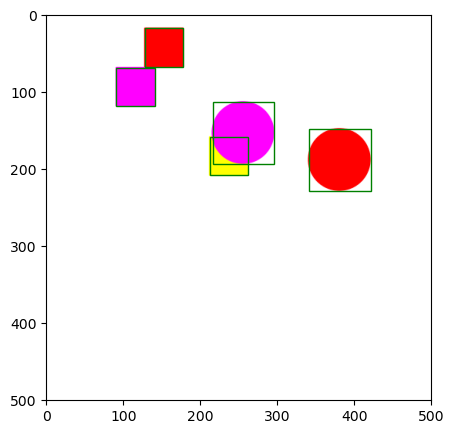

In [6]:
#step3.1: visualization for step 3
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import json
import os

def json_listing(json_data):
    label = []
    for region in json_data:
        label.append([region['x'], region['y'], region['w'], region['h']])
    return label

def bbox_plot(img, boxes):
    # Get image shape
    height, width = img.shape[0], img.shape[1]

    fig, ax = plt.subplots(figsize=(width/100, height/100))
    ax.set_xlim([0, width])
    ax.set_ylim([0, height])
    plt.gca().invert_yaxis()
    ax.imshow(img)

    for box in boxes:
        x, y, w, h = box
        rect = plt.Rectangle(
            (x, y), w, h,
            linewidth=1, edgecolor='g',
            facecolor="none"
        )
        ax.add_patch(rect)

    plt.show()

def bounding_boxes(dataset_dir):
    images_dir = os.path.join(dataset_dir, "images")
    labels_dir = os.path.join(dataset_dir, "labels_json")
    
    img_list = sorted([f for f in os.listdir(images_dir) if f.endswith(".png")])
    lab_list = sorted([f for f in os.listdir(labels_dir) if f.endswith(".json")])
    
    for img_file, lab_file in zip(img_list, lab_list):
        img_path = os.path.join(images_dir, img_file)
        lab_path = os.path.join(labels_dir, lab_file)
        
        img = plt.imread(img_path)
        print("Image:", img_file)
        print("Label:", lab_file)
        with open(lab_path, "r") as jf:
            box_data = json.load(jf)
            boxes = json_listing(box_data)
        
        bbox_plot(img, boxes)

# Now call the function inside the notebook
inline_dataset_dir = os.path.join(SHAPES_FOLDER, DATASET_NAME)
bounding_boxes(inline_dataset_dir)

In [7]:
#step4: Convert Labels to a Single COCO Annotations File
import os
import json
from tqdm import tqdm

def convert_to_coco(images_dir, labels_dir, output_json):
    """
    Combine each shapes_N.json bounding box file into a single COCO annotation JSON.
    """
    coco_data = {
        "images": [],
        "annotations": [],
        "categories": [
            {"id": 1, "name": "circle", "supercategory": "shape"},
            {"id": 2, "name": "rect", "supercategory": "shape"}
        ]
    }
    
    annotation_id = 1
    image_id = 1
    
    image_files = sorted([f for f in os.listdir(images_dir) if f.endswith(".png")])
    
    for img_file in tqdm(image_files):
        base_name = img_file.replace(".png", "")
        json_file = base_name + ".json"
        json_path = os.path.join(labels_dir, json_file)
        
        # Add image info
        coco_data["images"].append({
            "id": image_id,
            "file_name": img_file,
            "width": IMG_WIDTH,
            "height": IMG_HEIGHT
        })
        
        # Read bounding box info
        if os.path.exists(json_path):
            with open(json_path, "r") as f:
                bbox_data = json.load(f)
            
            for obj in bbox_data:
                shape_type = obj['object']
                category_id = 1 if shape_type == 'circle' else 2
                x, y, w, h = obj['x'], obj['y'], obj['w'], obj['h']
                
                coco_data["annotations"].append({
                    "id": annotation_id,
                    "image_id": image_id,
                    "category_id": category_id,
                    "bbox": [x, y, w, h],
                    "segmentation": [],
                    "area": w * h,
                    "iscrowd": 0
                })
                annotation_id += 1
        
        image_id += 1
    
    with open(output_json, "w") as f:
        json.dump(coco_data, f)
    print(f"COCO annotations saved to {output_json}")

images_dir = os.path.join(SHAPES_FOLDER, DATASET_NAME, "images")
labels_dir = os.path.join(SHAPES_FOLDER, DATASET_NAME, "labels_json")
output_coco = os.path.join(SHAPES_FOLDER, DATASET_NAME, "coco_annotations.json")

convert_to_coco(images_dir, labels_dir, output_coco)

100%|███████████████████████████████████████████| 1/1 [00:00<00:00, 2028.19it/s]

COCO annotations saved to shapes/shapes_dataset/coco_annotations.json


In [8]:
#step5: Load the Local SAM Model
from segment_anything import sam_model_registry, SamPredictor
import torch

CHECKPOINT_PATH = "./weights/sam_vit_h_4b8939.pth"

device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry["vit_h"](checkpoint=CHECKPOINT_PATH)
sam.to(device)
predictor = SamPredictor(sam)

print("✅ SAM model loaded locally on device:", device)

✅ SAM model loaded locally on device: cpu


In [26]:
#step6: Convert Binary Masks from SAM -> COCO Polygons
import cv2
import numpy as np

def mask_to_coco_poly(binary_mask):
    """
    Convert a single binary mask (H x W) into COCO polygon format.
    """
    contours, _ = cv2.findContours(binary_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polygons = []
    for contour in contours:
        contour = contour.flatten().tolist()
        if len(contour) >= 6:
            polygons.append(contour)
    return polygons

In [27]:
#step7: Segment with SAM Locally & Update COCO
def segment_with_local_sam(image_dir, input_coco, output_coco):
    with open(input_coco, "r") as f:
        coco_data = json.load(f)
    
    annotations_by_image = {}
    for ann in coco_data["annotations"]:
        img_id = ann["image_id"]
        annotations_by_image.setdefault(img_id, []).append(ann)
    
    for img_info in coco_data["images"]:
        image_id = img_info["id"]
        file_name = img_info["file_name"]
        width = img_info["width"]
        height = img_info["height"]
        
        full_img_path = os.path.join(image_dir, file_name)
        
        image_bgr = cv2.imread(full_img_path)
        if image_bgr is None:
            print(f"❌ Could not load image: {full_img_path}")
            continue

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        predictor.set_image(image_rgb)

        if image_id in annotations_by_image:
            for ann in annotations_by_image[image_id]:
                x, y, w, h = ann["bbox"]
                box = np.array([x, y, x + w, y + h])
                
                masks, scores, _ = predictor.predict(box=box, multimask_output=False)

                if masks.ndim == 2:
                    bin_mask = masks
                else:
                    bin_mask = masks[0]
                
                polygons = mask_to_coco_poly(bin_mask)
                ann["segmentation"] = polygons
    
    with open(output_coco, "w") as f:
        json.dump(coco_data, f)
    print(f"✅ COCO file updated with SAM segmentation: {output_coco}")

images_dir = os.path.join(SHAPES_FOLDER, DATASET_NAME, "images")
input_coco = os.path.join(SHAPES_FOLDER, DATASET_NAME, "coco_annotations.json")
output_coco = os.path.join(SHAPES_FOLDER, DATASET_NAME, "coco_annotations_with_masks.json")

segment_with_local_sam(images_dir, input_coco, output_coco)

✅ COCO file updated with SAM segmentation: shapes/shapes_dataset/coco_annotations_with_masks.json


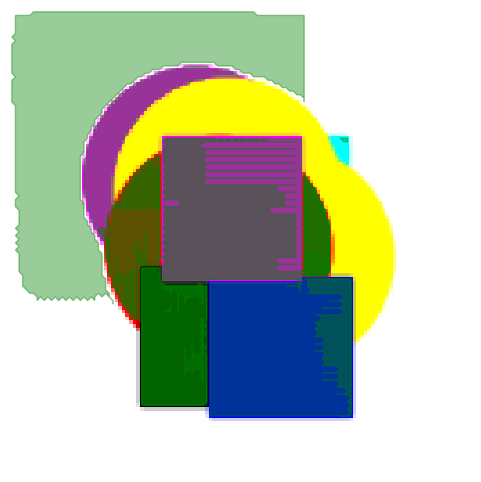

In [28]:
#step8: Visualize the New Segmentation Masks (Optional)
def visualize_sam_segmentation(image_path, polygons_list):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    
    for poly in polygons_list:
        poly_np = np.array(poly).reshape((-1, 2))
        plt.fill(poly_np[:, 0], poly_np[:, 1], color='green', alpha=0.4)
    plt.axis('off')
    plt.show()

import json
with open(output_coco, 'r') as f:
    coco_data = json.load(f)

first_image = coco_data["images"][0]
img_id = first_image["id"]
image_path = os.path.join(images_dir, first_image["file_name"])

ann_for_img = [a for a in coco_data["annotations"] if a["image_id"] == img_id]

all_polys = []
for ann in ann_for_img:
    all_polys.extend(ann.get("segmentation", []))

visualize_sam_segmentation(image_path, all_polys)